This Notebook provides an example of the MaskedDiffusionLanguageModel's ability to model some elementary data.

In [3]:
using Diffusions, Random, StatsBase, Flux, OneHotArrays, Distributions, Plots, Random, StatsPlots, LaTeXStrings
using Flux
using NNlib
using Random
using LinearAlgebra
include("diffusion.jl")
include("loss.jl")
include("Diffusions.jl/src/maskedarrays.jl")
rng = Random.default_rng()

TaskLocalRNG()

# Helper Functions

In [4]:
# This function runs into errors due to the Process type defined in Diffusions.jl
# Therefore, it is called here once again to resolve this error
# This problem will disappear when the MaskedDiffusionLanguageModels are integrated into the package

import Diffusions: sampleforward

function sampleforward(rng::AbstractRNG, process::Process, t::Real, x::AbstractArray)
    x = copy(x)
    maskedvec(x) .= _sampleforward(rng, process, t, maskedvec(x))
    return x
end

function sampleforward(rng::AbstractRNG, process::Process, t::AbstractVector{<:Real}, x::AbstractArray)
    x = copy(x)
    for i in axes(x, ndims(x))
        maskedvec(x, i) .= _sampleforward(rng, process, t[i], maskedvec(x, i))
    end
    return x
end


sampleforward (generic function with 6 methods)

In [5]:
import Diffusions: eq_dist
eq_dist(model::MaskedDiffusionLanguageModel) = Categorical(model.vocab_size)

eq_dist (generic function with 5 methods)

In [6]:
# These functions run into the same problems as the ones mentioned above

import Diffusions: samplebackward

function checktimesteps(timesteps)
    length(timesteps) ≥ 2 || throw(ArgumentError("timesteps must have at least two timesteps"))
    issorted(timesteps) || throw(ArgumentError("timesteps must be increasing"))
    all(>(0), timesteps) || throw(ArgumentError("all timesteps must be positive"))
end

struct NullTracker end

track!(::NullTracker, t, x, x0) = nothing


struct Tracker
    time::Vector
    data::Vector
    x0::Vector
end

Tracker() = Tracker([], [], [])

function track!(tracker::Tracker, t, x, x0)
    push!(tracker.time, t)
    push!(tracker.data, x)
    push!(tracker.x0, x0)
    return nothing
end


function samplebackward(rng::AbstractRNG, guess, process, timesteps, x; tracker=NullTracker())
    checktimesteps(timesteps)
    i = lastindex(timesteps)
    t = timesteps[i]
    while i > firstindex(timesteps)
        s = timesteps[i-1]
        x_0 = guess(x, t)
        x = endpoint_conditioned_sample(rng, process, s, t, x_0, x)
        # @show x
        # track!(tracker, s, x, x_0)
        t = s
        i -= 1
    end
    return x
end

samplebackward (generic function with 2 methods)

In [7]:
function endpoint_conditioned_sample(rng::AbstractRNG, process::Process, s::Real, t::Real, x_0::AbstractArray, x_t::AbstractArray)
    if x_t isa MaskedArray
        # x_0 inherits masked elements from x_t
        x_0 = MaskedArray(x_0, x_t.indices)
    end
    x = copy(x_t)
    maskedvec(x) .= _endpoint_conditioned_sample(rng, process, s, t, maskedvec(x_0), maskedvec(x_t))
    return x
end

endpoint_conditioned_sample(rng::AbstractRNG, process, s::Real, t::Real, x_0, x_t) =
    endpoint_conditioned_sample.(rng, process, s, t, x_0, x_t)

# sample x at time s conditioned on x_0 at time 0 and x_t at time t
endpoint_conditioned_sample(P::Process, s::Real, t::Real, x_0, x_t) = endpoint_conditioned_sample(Random.default_rng(), P, s, t, x_0, x_t)


endpoint_conditioned_sample (generic function with 3 methods)

In [8]:
#=
function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractVector{Bool})
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    vocab_size = process.vocab_size  # Assume this is a field in your MaskedDiffusionLanguageModel
    num_tokens = length(x) ÷ vocab_size
    
    result = falses(length(x))
    
    for i in 1:num_tokens
        token_slice = (i-1)*vocab_size + 1 : i*vocab_size
        if rand(rng) < p_keep
            # Keep the original token
            result[token_slice] = x[token_slice]
        else
            # Mask the token
            result[token_slice[process.mask_token_id]] = true
        end
    end
    
    return result
end

function _sampleforward(rng::AbstractRNG, process::MaskedDiffusionLanguageModel, t::Real, x::AbstractArray{Bool, 3})
    vocab_size, batch_size, seq_length = size(x)
    
    # Get the keep probability
    α_t = process.α(t)[1]  # Extract the first element of the tuple
    p_keep = α_t  # Assuming α_t directly gives the keep probability
    
    result = falses(size(x))
    
    for k in 1:seq_length
        for j in 1:batch_size
            if rand(rng) < p_keep
                # Keep the original token
                result[:, j, k] = x[:, j, k]
            else
                # Mask the token
                result[process.mask_token_id, j, k] = true
            end
        end
    end
    
    return result
end
=#

# The Data

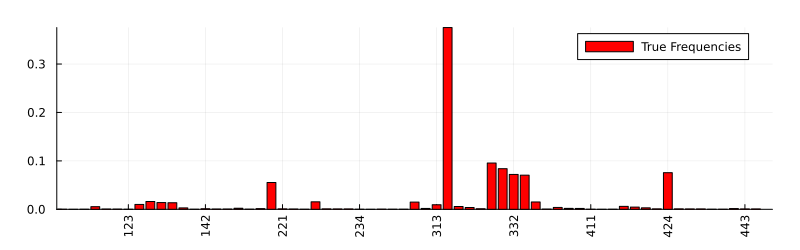

In [9]:
#Setting up a toy Markov sequence generator
S = [0.06591801058555521, 0.07969206822877058, 0.7577065839917972, 0.09668333719387696]
M1 = [0.08846562872099392 0.16990851783433247 0.7057593661240716 0.035866487320601916; 0.7431475939699389 0.21587009667771628 0.03183492266912633 0.009147386683218569; 0.5299436666548881 0.14037279287634963 0.31880667650890665 0.010876863959855763; 0.06768187476034546 0.8712803961334261 0.026959057317955764 0.03407867178827272]
M2 = [0.03711853694508748 0.004654670142378095 0.02356516471832978 0.9346616281942046; 0.05468190341435613 0.035849693778767566 0.010983526474084716 0.8984848763327916; 0.34718976966999127 0.29844003126407787 0.29174999882526814 0.06262020024066273; 0.06343354243884528 0.46980429610053 0.23584821143715762 0.23091395002346707]


#=
#If you wanted to draw the seq gen randomly
S = exp.(randn(4) .* 1.5)
S ./= sum(S)

M1 = exp.(randn(4,4) .* 1.5)
M1 ./= sum(M1 , dims = 2)

M2 = exp.(randn(4,4) .* 1.5)
M2 ./= sum(M2 , dims = 2)
=#


function target_sample(;S = S, M1 = M1, M2 = M2)
    a = rand(Categorical(S))
    b = rand(Categorical(M1[a,:]))
    c = rand(Categorical(M2[b,:]))
    return [a,b,c]
end

seq_matrix = hcat([[k,j,i] for i in 1:4, j in 1:4, k in 1:4]...)
all_seqs = [seq_matrix[:,i] for i in 1:size(seq_matrix,2)];
prob_seq(seq,S,M1,M2) = S[seq[1]]*M1[seq[1],seq[2]]*M2[seq[2],seq[3]]
all_probs = prob_seq.(all_seqs,Ref(S),Ref(M1),Ref(M2));

bar([join(string.(a)) for a in all_seqs], all_probs,
    xrotation = 90, size = (800,250), label = "True Frequencies",
    color = "red", margins = 0.5Plots.cm, xlim = (0,65))

# The Model

In [15]:
#Setting up the timestep schedule
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)
alph = 5
#Define the discrete diffusion process
# P = UniformDiscreteDiffusion(1.0,alph)
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

batch_size = 8
# ps = Flux.params(embed, decode)
opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.0001))#Adam(0.001))
cumu_loss = 0.0
training_losses = Float64[];

# The Transformer

In [12]:
struct RotaryEmbedding
    inv_freq::Vector{Float32}
end

function RotaryEmbedding(dim::Int; base::Float32=10000f0)
    inv_freq = 1f0 ./ (base .^ (range(0f0, 1f0, length=div(dim, 2)) .* (2f0 / dim)))
    RotaryEmbedding(inv_freq)
end

function (re::RotaryEmbedding)(x::AbstractArray)
    seq_len = size(x, 2)
    t = range(0, seq_len-1)
    freqs = t' .* re.inv_freq
    emb = vcat(freqs, freqs)
    cos_rot = cos.(emb)
    sin_rot = sin.(emb)
    return cos_rot, sin_rot
end

function rotate_half(x::AbstractArray)
    x1, x2 = x[1:div(end,2), :, :, :], x[div(end,2)+1:end, :, :, :]
    return vcat(-x2, x1)
end

function apply_rotary_emb(x::AbstractArray, cos::AbstractArray, sin::AbstractArray)
    cos = reshape(cos, 1, size(cos)..., 1)
    sin = reshape(sin, 1, size(sin)..., 1)
    return x * cos + rotate_half(x) * sin
end

apply_rotary_emb (generic function with 1 method)

## Timestep Embedding

In [8]:
# NEW TIMESTEP

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::AbstractVector, freqs::Vector{Float32})
    args = t[:, :] .* freqs'
    embedding = vcat(sin.(args), cos.(args))
    if size(embedding, 1) % 2 == 1
        embedding = vcat(embedding, zeros(Float32, 1, length(t)))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::AbstractVector)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

# Test TimestepEmbedder
function test_timestep_embedder()
    dim = 64
    batch_size = 32
    
    te = TimestepEmbedder(dim)
    t = rand(Float32, batch_size)
    
    output = te(t)
    
    println("TimestepEmbedder test:")
    println("Input shape: ", size(t))
    println("Frequency embedding shape: ", size(timestep_embedding(t, te.freqs)))
    println("Output shape: ", size(output))
    
    @assert size(output) == (dim, batch_size) "Output size mismatch"
    
    println("TimestepEmbedder test passed!")
end

test_timestep_embedder()

TimestepEmbedder test:
Input shape: (32,)
Frequency embedding shape: (64, 32)
Output shape: (64, 32)
TimestepEmbedder test passed!


In [24]:
function test_timestep_embedder()
    cond_dim = 64
    batch_size = 32

    te = TimestepEmbedder(cond_dim)
    t = rand(Float32, batch_size)

    output = te(t)

    println("TimestepEmbedder test:")
    println("Input shape: ", size(t))
    println("Output shape: ", size(output))
    println("Output type: ", eltype(output))

    @assert size(output) == (cond_dim, batch_size) "Output size mismatch"
    @assert eltype(output) == Float32 "Output type mismatch"

    println("TimestepEmbedder test passed!")
end

test_timestep_embedder()

TimestepEmbedder test:
Input shape: (32,)
Output shape: (64, 32)
Output type: Float32
TimestepEmbedder test passed!


In [8]:
struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractMatrix)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, size(scale, 2))) .+ reshape(shift, :, 1, size(shift, 2))
end

struct TransformerLayer
    attention::MultiHeadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiHeadAttention(dim; nheads=n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, cond::AbstractMatrix)
    # Self-attention
    normalized = layer.norm1(x, cond)
    attention_output, _ = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    
    # Feedforward
    x = x + layer.ff(layer.norm2(x, cond))
    
    return x
end

## adaLN

In [14]:
#= using Flux
using NNlib
using Random

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end =#

In [6]:
function test_adaln()
    dim = 128
    cond_dim = 64
    seq_len = 3
    batch_size = 32

    aln = AdaLN(dim, cond_dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cond = randn(Float32, cond_dim)

    output = aln(x, cond)

    println("AdaLN test:")
    println("Input shape: ", size(x))
    println("Condition shape: ", size(cond))
    println("Output shape: ", size(output))
    println("Output type: ", eltype(output))

    @assert size(output) == size(x) "Output size mismatch"
    @assert eltype(output) == Float32 "Output type mismatch"

    println("AdaLN test passed!")
end

test_adaln()

AdaLN test:
Input shape: (128, 3, 32)
Condition shape: (64,)
Output shape: (128, 3, 32)
Output type: Float32
AdaLN test passed!


In [15]:
#= struct TransformerLayer
    attention::MultiHeadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiHeadAttention(dim; nheads=n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, cond::AbstractVector)
    # Self-attention
    normalized = layer.norm1(x, cond)
    attention_output, _ = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    
    # Feedforward
    x = x + layer.ff(layer.norm2(x, cond))
    
    return x
end =# 

In [9]:
function test_transformer_layer()
    dim = 128
    n_head = 8
    cond_dim = 64
    seq_len = 3
    batch_size = 32

    layer = TransformerLayer(dim, n_head, cond_dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cond = randn(Float32, cond_dim)

    output = layer(x, cond)

    println("TransformerLayer test:")
    println("Input shape: ", size(x))
    println("Condition shape: ", size(cond))
    println("Output shape: ", size(output))
    println("Output type: ", eltype(output))

    @assert size(output) == size(x) "Output size mismatch"
    @assert eltype(output) == Float32 "Output type mismatch"
    @assert !all(output .≈ x) "Output should be different from input"

    println("TransformerLayer test passed!")
end

test_transformer_layer() 

TransformerLayer test:
Input shape: (128, 3, 32)
Condition shape: (64,)
Output shape: (128, 3, 32)
Output type: Float32
TransformerLayer test passed!


# DiT 

In [12]:
#=using Flux
using NNlib
using Random

struct DIT
    token_embed::Dense
    pos_embed::Matrix{Float32}
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),  # No bias for token embedding
        randn(Float32, dim, seq_len),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::AbstractVector)
    # x is expected to be of shape (vocab_size, seq_len, batch_size)
    # t is expected to be of shape (batch_size,)
    
    # Embed tokens and add positional encoding
    x = model.token_embed(x)
    x = x .+ model.pos_embed[:, 1:size(x, 2)]
    
    # Embed time
    t_embed = model.time_embed(t)
    
    # Pass through transformer layers
    for layer in model.layers
        x = layer(x, t_embed)
    end
    
    # Final normalization and output
    x = model.final_norm(x, t_embed)
    return model.final_layer(x)
end =# 

In [26]:
using Flux
using NNlib
using Random

mutable struct DIT
    token_embed::Dense
    pos_embed::Matrix{Float32}
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Flux.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),  # No bias for token embedding
        randn(Float32, dim, seq_len),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::AbstractVector)
    # x is expected to be of shape (vocab_size, seq_len, batch_size)
    # t is expected to be of shape (batch_size,)
    
    # Embed tokens and add positional encoding
    x = model.token_embed(x)
    x = x .+ model.pos_embed[:, 1:size(x, 2)]
    
    # Embed time
    t_embed = model.time_embed(t)
    
    # Pass through transformer layers
    for layer in model.layers
        x = layer(x, t_embed)
    end
    
    # Final normalization and output
    x = model.final_norm(x, t_embed)
    return model.final_layer(x)
end

In [27]:

function test_dit_model()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 32

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t = rand(Float32, batch_size)

    @show x
    @show t

    output = model(x, t)

    println("DIT model test:")
    println("Input shape: ", size(x))
    println("Timestep shape: ", size(t))
    println("Output shape: ", size(output))
    println("Output type: ", eltype(output))

    @assert size(output) == (vocab_size, seq_len, batch_size) "Output size mismatch"
    @assert eltype(output) == Float32 "Output type mismatch"

    # Test that the output is different for different timesteps
    output2 = model(x, rand(Float32, batch_size))
    @assert !all(output .≈ output2) "Output should be different for different timesteps"

    println("DIT model test passed!")
end

test_dit_model()

x = Float32[0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 1.0 0.0; 0.0 0.0 0.0; 1.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 1.0 0.0; 1.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 1.0 1.0; 0.0 0.0 0.0; 1.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0; 1.0 0.0 0.0; 0.0 1.0 1.0;;; 0.0 0.0 0.0; 1.0 0.0 0.0; 0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 1.0 0.0;;; 0.0 0.0 0.0; 1.0 0.0 1.0; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 1.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 0.0; 1.0 0.0 0.0; 0.0 1.0 1.0; 0.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 0.0 1.0; 1.0 0.0 0.0; 0.0 0.0 0.0; 0.0 1.0 0.0;;; 0.0 1.0 0.0; 0.0 0.0 0.0; 0.0 0.0 1.0; 1.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 1.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0; 1.0 0.0 1.0; 0.0 0.0 0.0;;; 0.0 0.0 1.0; 0.0 0.0 0.0; 0.0 1.0 0.0; 1.0 0.0 0.0; 0.0 0.0 0.0;;; 0.0 1.0 0.0; 0.0 0.0 0.0; 0.0 0.0 1.0; 0.0 0.0 0.0; 1.0 0.0 0.0;;; 0.0 1.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 1.0; 1.0 0.0 0.0;;; 0.0 0.0 0.0; 0.0 1.0 0.0; 1.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 1.0;;; 1.0 0.0 0.0; 0.0 0.0 0.0; 0.0 0.0 0.0; 0.0 1.0 0.0

## Multihead Attention

In [1]:
# MultiHeadAttention
struct MultiHeadAttention
    W_q::Dense
    W_k::Dense
    W_v::Dense
    W_o::Dense
    n_head::Int
end

function MultiHeadAttention(dim::Int, n_head::Int)
    head_dim = div(dim, n_head)
    MultiHeadAttention(
        Dense(dim, dim, bias=false),
        Dense(dim, dim, bias=false),
        Dense(dim, dim, bias=false),
        Dense(dim, dim, bias=false),
        n_head
    )
end

function (mha::MultiHeadAttention)(x::AbstractArray)
    q, k, v = mha.W_q(x), mha.W_k(x), mha.W_v(x)
    
    # Reshape for multi-head attention
    batch_size = size(x, 3)
    q = reshape(q, :, mha.n_head, size(q, 2), batch_size)
    k = reshape(k, :, mha.n_head, size(k, 2), batch_size)
    v = reshape(v, :, mha.n_head, size(v, 2), batch_size)
    
    # Perform attention
    out, _ = NNlib.dot_product_attention(q, k, v)
    
    # Reshape output
    out = reshape(out, :, size(x, 2), batch_size)
    
    return mha.W_o(out)
end

LoadError: UndefVarError: `Dense` not defined

## DiT (OLD)

In [10]:
using Flux
using NNlib
using Random

struct DIT
    token_embed::Dense
    pos_embed::Matrix{Float32}
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_layer::Dense
end

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int)
    DIT(
        Dense(vocab_size, dim),
        randn(Float32, dim, seq_len),
        TimestepEmbedder(dim),
        [TransformerLayer(dim, n_heads) for _ in 1:n_layers],
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::AbstractVector)
    # x is expected to be of shape (vocab_size, seq_len, batch_size)
    # t is expected to be of shape (batch_size,)
    
    # Embed tokens and add positional encoding
    x = model.token_embed(x)
    x = x .+ model.pos_embed[:, 1:size(x, 2)]
    
    # Embed time
    t_embed = model.time_embed(t)
    
    # Add time embedding to each position
    x = x .+ reshape(t_embed, size(t_embed, 1), 1, size(t_embed, 2))
    
    # Pass through transformer layers
    for layer in model.layers
        x = layer(x)
    end
    
    # Final layer
    return model.final_layer(x)
end


In [11]:
function test_dit_model()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    batch_size = 64

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t = rand(Float32, batch_size)

    output = model(x, t)

    println("DIT model test:")
    println("Input shape: ", size(x))
    println("Timestep shape: ", size(t))
    println("Output shape: ", size(output))
    println("Output type: ", eltype(output))

    @assert size(output) == (vocab_size, seq_len, batch_size) "Output size mismatch"
    @assert eltype(output) == Float32 "Output type mismatch"

    # Test intermediate shapes
    token_embed_output = model.token_embed(x)
    @assert size(token_embed_output) == (dim, seq_len, batch_size) "Token embedding shape mismatch"

    time_embed_output = model.time_embed(t)
    @assert size(time_embed_output) == (dim, batch_size) "Time embedding shape mismatch"

    # Test that the output is different for different timesteps
    output2 = model(x, rand(Float32, batch_size))
    @assert !all(output .≈ output2) "Output should be different for different timesteps"

    println("DIT model test passed!")
end

# Run the test
test_dit_model()

LoadError: MethodError: no method matching TransformerLayer(::Int64, ::Int64)

[0mClosest candidates are:
[0m  TransformerLayer(::Int64, ::Int64, [91m::Int64[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[8]:8[24m[39m
[0m  TransformerLayer(::Any, ::Any, [91m::Any[39m, [91m::Any[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[8]:2[24m[39m


In [5]:
# Test the improved model
vocab_size = 5
seq_len = 3
dim = 128
n_layers = 4
n_heads = 8
batch_size = 64

model = DIT(vocab_size, seq_len, dim, n_layers, n_heads)
x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
t = rand(Float32, batch_size)

output = model(x, t)
println("Improved DIT output shape: ", size(output))  # Should be (5, 3, 64)

LoadError: MethodError: no method matching exp(::StepRangeLen{Float32, Float64, Float64, Int64})

[0mClosest candidates are:
[0m  exp([91m::BigFloat[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mmpfr.jl:674[24m[39m
[0m  exp([91m::Missing[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mmath.jl:1580[24m[39m
[0m  exp([91m::ComplexF16[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mmath.jl:1564[24m[39m
[0m  ...


In [13]:
?time_embed

LoadError: InterruptException:

## Old Version

In [1]:
using Flux
using NNlib
using Random

# Set a random seed for reproducibility
Random.seed!(123)

# Define model parameters
vocab_size = 5  # Including mask token
seq_len = 3
d_model = 128  # Increased from 64
n_head = 8     # Increased from 4
n_layer = 4    # Increased from 2
dropout_rate = 0.1f0  # Explicitly Float32

# Improved positional encoding
function positional_encoding(seq_len::Int, d_model::Int)
    pe = zeros(Float32, d_model, seq_len)
    for pos in 1:seq_len
        for i in 1:2:d_model
            pe[i, pos] = sin(pos / (10000 ^ ((i-1) / d_model)))
            pe[i+1, pos] = cos(pos / (10000 ^ ((i-1) / d_model)))
        end
    end
    return pe
end

# Improved Multi-Head Attention
struct MultiHeadAttention
    W_q::Dense
    W_k::Dense
    W_v::Dense
    W_o::Dense
    n_head::Int
end

function MultiHeadAttention(d_model::Int, n_head::Int)
    head_dim = div(d_model, n_head)
    MultiHeadAttention(
        Dense(d_model, d_model, bias=false),
        Dense(d_model, d_model, bias=false),
        Dense(d_model, d_model, bias=false),
        Dense(d_model, d_model, bias=false),
        n_head
    )
end

function (mha::MultiHeadAttention)(x)
    q, k, v = mha.W_q(x), mha.W_k(x), mha.W_v(x)
    
    # Reshape for multi-head attention
    batch_size = size(x, 3)
    q = reshape(q, :, mha.n_head, size(q, 2), batch_size)
    k = reshape(k, :, mha.n_head, size(k, 2), batch_size)
    v = reshape(v, :, mha.n_head, size(v, 2), batch_size)
    
    # Perform attention
    out, _ = NNlib.dot_product_attention(q, k, v)
    
    # Reshape output
    out = reshape(out, :, size(x, 2), batch_size)
    
    return mha.W_o(out)
end


# Improved Transformer Layer with residual connections
struct TransformerLayer
    mha::MultiHeadAttention
    ff::Chain
    norm1::LayerNorm
    norm2::LayerNorm
    dropout::Dropout
end

function TransformerLayer(d_model::Int, n_head::Int, d_ff::Int, dropout_rate::Float32)
    TransformerLayer(
        MultiHeadAttention(d_model, n_head),
        Chain(Dense(d_model, d_ff, gelu), Dense(d_ff, d_model)),
        LayerNorm(d_model),
        LayerNorm(d_model),
        Dropout(dropout_rate)
    )
end

function (layer::TransformerLayer)(x)
    # Self-attention with residual connection
    x = x + layer.dropout(layer.mha(layer.norm1(x)))
    
    # Feedforward with residual connection
    x = x + layer.dropout(layer.ff(layer.norm2(x)))
    
    return x
end

# Improved Transformer model
struct MDLMTransformer
    token_embed::Dense
    pos_embed::Matrix{Float32}
    time_embed::Chain
    layers::Vector{TransformerLayer}
    output_layer::Dense
    norm::LayerNorm
end

function MDLMTransformer(vocab_size::Int, seq_len::Int, d_model::Int, n_head::Int, n_layer::Int, dropout_rate::Float32)
    MDLMTransformer(
        Dense(vocab_size, d_model),
        positional_encoding(seq_len, d_model),
        Chain(Dense(1, d_model), Dense(d_model, d_model)),
        [TransformerLayer(d_model, n_head, d_model * 4, dropout_rate) for _ in 1:n_layer],
        Dense(d_model, vocab_size),
        LayerNorm(d_model)
    )
end

function (model::MDLMTransformer)(x::AbstractArray, t::Real)
    # Ensure input is Float32
    x = Float32.(x)
    t = Float32(t)
    
    # Embed tokens and add positional encoding
    e = model.token_embed(x)
    e = e .+ model.pos_embed[:, 1:size(x, 2)]
    
    # Embed time and add to each position
    t_emb = model.time_embed(reshape([t], 1, 1))
    e = e .+ reshape(t_emb, :, 1, 1)
    
    # Pass through transformer layers
    for layer in model.layers
        e = layer(e)
    end
    
    # Final layer norm before output
    e = model.norm(e)
    
    # Output layer
    return model.output_layer(e)
end

# Create the model
model = MDLMTransformer(vocab_size, seq_len, d_model, n_head, n_layer, Float32(dropout_rate))

# Test the model with dummy data
batch_size = 32
x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
t = rand(Float32)  # Single timestep

output = model(x, t)
println("Output shape: ", size(output))  # Should be (vocab_size, seq_len, batch_size) 

Output shape: (5, 3, 32)


# TESTING TESTING

In [8]:
struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

function test_adaln()
    dim = 64
    cond_dim = 32
    seq_len = 10
    batch_size = 2
    
    aln = AdaLN(dim, cond_dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cond = randn(Float32, cond_dim)
    
    output = aln(x, cond)
    
    println("AdaLN test:")
    println("Input shape: ", size(x))
    println("Condition shape: ", size(cond))
    println("Output shape: ", size(output))
    
    @assert size(output) == size(x) "Output size mismatch"
    
    println("AdaLN test passed!")
end

test_adaln()

AdaLN test:
Input shape: (64, 10, 2)
Condition shape: (32,)
Output shape: (64, 10, 2)
AdaLN test passed!


In [1]:
struct RotaryEmbedding
    inv_freq::Vector{Float32}
end

function RotaryEmbedding(dim::Int; base::Float32 = 10000f0)
    inv_freq = 1f0 ./ (base .^ (Float32.(0:2:dim-1) ./ dim))
    RotaryEmbedding(inv_freq)
end

function (re::RotaryEmbedding)(x::AbstractArray)
    seq_len = size(x, 2)
    t = reshape(Float32.(0:seq_len-1), 1, :)
    freqs = t .* reshape(re.inv_freq, :, 1)
    emb = vcat(freqs, freqs)
    cos_rot = cos.(emb)
    sin_rot = sin.(emb)
    return cos_rot, sin_rot
end

function apply_rotary_emb(x::AbstractArray, cos::AbstractArray, sin::AbstractArray)
    dim, seq_len = size(x, 1), size(x, 2)
    x_rot = similar(x)
    x_rot[1:2:end, :, :] = x[1:2:end, :, :] .* cos[1:2:end, :] .- x[2:2:end, :, :] .* sin[1:2:end, :]
    x_rot[2:2:end, :, :] = x[2:2:end, :, :] .* cos[2:2:end, :] .+ x[1:2:end, :, :] .* sin[2:2:end, :]
    return x_rot
end

apply_rotary_emb (generic function with 1 method)

In [19]:
# NEW
using Flux

struct RotaryEmbedding
    dim::Int
    max_seq_len::Int
    θ::Vector{Float32}
    
    function RotaryEmbedding(dim::Int; max_seq_len::Int=512, base::Int=10000)
        θ = [1.0 / (base^(i / dim)) for i in 0:2:dim-1]
        new(dim, max_seq_len, θ)
    end
end

function (re::RotaryEmbedding)(x::AbstractArray)
    _, _, seq_len, _ = size(x)
    t = reshape(Float32.(1:seq_len), 1, 1, seq_len, 1)
    freqs = t .* reshape(re.θ, :, 1, 1, 1)
    emb = repeat(freqs, outer=(2, 1, 1, 1))
    cos_rot = cos.(emb)
    sin_rot = sin.(emb)
    return cos_rot, sin_rot
end

function apply_rotary_emb(x::AbstractArray, cos::AbstractArray, sin::AbstractArray)
    x1, x2 = x[1:2:end, :, :, :], x[2:2:end, :, :, :]
    ro_x = vcat(x1 .* cos .- x2 .* sin, x1 .* sin .+ x2 .* cos)
    return ro_x
end

apply_rotary_emb (generic function with 1 method)

In [20]:
# Test RotaryEmbedding
function test_rotary_embedding()
    dim = 64
    seq_len = 10
    batch_size = 2
    re = RotaryEmbedding(dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cos_rot, sin_rot = re(x)
    
    println("RotaryEmbedding test:")
    println("Input shape: ", size(x))
    println("cos_rot shape: ", size(cos_rot))
    println("sin_rot shape: ", size(sin_rot))
    
    @assert size(cos_rot) == (dim, seq_len) "cos_rot size mismatch"
    @assert size(sin_rot) == (dim, seq_len) "sin_rot size mismatch"
    
    println("RotaryEmbedding test passed!")
end
test_rotary_embedding()

# Test apply_rotary_emb
function test_apply_rotary_emb()
    dim = 64
    seq_len = 10
    batch_size = 2
    re = RotaryEmbedding(dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cos_rot, sin_rot = re(x)
    x_rot = apply_rotary_emb(x, cos_rot, sin_rot)
    
    println("apply_rotary_emb test:")
    println("Input shape: ", size(x))
    println("Rotated shape: ", size(x_rot))
    
    @assert size(x_rot) == size(x) "Rotated size mismatch"
    
    println("apply_rotary_emb test passed!")
end

test_apply_rotary_emb()

LoadError: BoundsError: attempt to access Tuple{Int64, Int64, Int64} at index [4]

In [21]:
# Test RotaryEmbedding
function test_rotary_embedding()
    dim = 64
    seq_len = 10
    batch_size = 2
    re = RotaryEmbedding(dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cos_rot, sin_rot = re(x)
    
    println("RotaryEmbedding test:")
    println("Input shape: ", size(x))
    println("cos_rot shape: ", size(cos_rot))
    println("sin_rot shape: ", size(sin_rot))
    
    @assert size(cos_rot) == (dim, seq_len) "cos_rot size mismatch"
    @assert size(sin_rot) == (dim, seq_len) "sin_rot size mismatch"
    
    println("RotaryEmbedding test passed!")
end

test_rotary_embedding()

# Test apply_rotary_emb
function test_apply_rotary_emb()
    dim = 64
    seq_len = 10
    batch_size = 2
    re = RotaryEmbedding(dim)
    x = randn(Float32, dim, seq_len, batch_size)
    cos_rot, sin_rot = re(x)
    x_rot = apply_rotary_emb(x, cos_rot, sin_rot)
    
    println("apply_rotary_emb test:")
    println("Input shape: ", size(x))
    println("Rotated shape: ", size(x_rot))
    
    @assert size(x_rot) == size(x) "Rotated size mismatch"
    
    println("apply_rotary_emb test passed!")
end

test_apply_rotary_emb()

LoadError: BoundsError: attempt to access Tuple{Int64, Int64, Int64} at index [4]

In [22]:
struct MultiHeadAttentionRoPE
    rotary::RotaryEmbedding
    q_proj::Dense
    k_proj::Dense
    v_proj::Dense
    out::Dense
    nheads::Int
end

function MultiHeadAttentionRoPE(dim::Int; nheads::Int=8)
    head_dim = dim ÷ nheads
    MultiHeadAttentionRoPE(
        RotaryEmbedding(head_dim),
        Dense(dim, dim),
        Dense(dim, dim),
        Dense(dim, dim),
        Dense(dim, dim),
        nheads
    )
end

function (mha::MultiHeadAttentionRoPE)(x::AbstractArray; mask=nothing)
    dim, seq_len, batch_size = size(x)
    head_dim = dim ÷ mha.nheads
    
    # Separate projections for Q, K, V
    q = mha.q_proj(x)
    k = mha.k_proj(x)
    v = mha.v_proj(x)
    
    # Reshape for multi-head
    q = reshape(q, head_dim, mha.nheads, seq_len, batch_size)
    k = reshape(k, head_dim, mha.nheads, seq_len, batch_size)
    v = reshape(v, head_dim, mha.nheads, seq_len, batch_size)
    
    # Apply rotary embeddings
    cos_rot, sin_rot = mha.rotary(q)
    q = apply_rotary_emb(q, cos_rot, sin_rot)
    k = apply_rotary_emb(k, cos_rot, sin_rot)
    
    # Prepare inputs for dot_product_attention
    q = permutedims(q, (1, 3, 2, 4))
    k = permutedims(k, (1, 3, 2, 4))
    v = permutedims(v, (1, 3, 2, 4))
    
    # Apply dot_product_attention
    scale = Float32(1 / sqrt(head_dim))
    attention_output, _ = NNlib.dot_product_attention(q, k, v; scale=scale, mask=mask)
    
    # Reshape and apply output projection
    attention_output = permutedims(attention_output, (1, 3, 2, 4))
    attention_output = reshape(attention_output, dim, seq_len, batch_size)
    output = mha.out(attention_output)
    
    return output
end

In [23]:
function test_multihead_attention_rope()
    dim = 64
    nheads = 8
    seq_len = 10
    batch_size = 2

    mha_rope = MultiHeadAttentionRoPE(dim; nheads=nheads)
    x = randn(Float32, dim, seq_len, batch_size)

    output = mha_rope(x)
    
    println("MultiHeadAttentionRoPE test:")
    println("Input shape: ", size(x))
    println("Output shape: ", size(output))
    
    @assert size(output) == size(x) "Output size mismatch"
    
    println("MultiHeadAttentionRoPE test passed!")
end

test_multihead_attention_rope()

LoadError: DimensionMismatch: arrays could not be broadcast to a common size; got a dimension with lengths 4 and 8

# Working Model

In [8]:
struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractMatrix)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, size(scale, 2))) .+ reshape(shift, :, 1, size(shift, 2))
end

In [16]:
struct TransformerLayer
    attention::MultiHeadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiHeadAttention(dim; nheads=n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dropout(0.3),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, cond::AbstractMatrix)
    # Self-attention
    normalized = layer.norm1(x, cond)
    attention_output, _ = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    
    # Feedforward
    x = x + layer.ff(layer.norm2(x, cond))
    
    return x
end

In [17]:
struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

In [18]:
mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Flux.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    # x is expected to be of shape (vocab_size, seq_len, batch_size)
    # t is now a single scalar value
    
    # Embed tokens (no positional encoding needed with RoPE)
    x = model.token_embed(x)
    
    # Embed time
    t_embed = model.time_embed(t)
    
    # Expand t_embed to match the batch size
    t_embed = repeat(t_embed, 1, size(x, 3))
    
    # Pass through transformer layers
    for layer in model.layers
        x = layer(x, t_embed)
    end
    
    # Final normalization and output
    x = model.final_norm(x, t_embed)
    return model.final_layer(x)
end

In [19]:
function test_dit_model_single_timestep()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 32

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t = rand(Float32)  # Single timestep

    println("DIT model with single timestep test:")
    println("Input shape: ", size(x))
    println("Timestep: ", t)

    # Test time embedding
    t_embed = model.time_embed(t)
    println("Time embedding shape: ", size(t_embed))
    @assert size(t_embed) == (cond_dim,) "Time embedding size mismatch"

    # Test token embedding
    token_embed = model.token_embed(x)
    println("Token embedding shape: ", size(token_embed))
    @assert size(token_embed) == (dim, seq_len, batch_size) "Token embedding size mismatch"

    # Test full forward pass
    output = model(x, t)
    println("Output shape: ", size(output))
    @assert size(output) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    # Test that the output is different for different timesteps
    output2 = model(x, rand(Float32))
    @assert !all(output .≈ output2) "Output should be different for different timesteps"

    println("DIT model with single timestep test passed!")
end

test_dit_model_single_timestep()

DIT model with single timestep test:
Input shape: (5, 3, 32)
Timestep: 0.6052523
Time embedding shape: (64,)
Token embedding shape: (128, 3, 32)
Output shape: (5, 3, 32)
DIT model with single timestep test passed!


# RoPE Implementation

## VERSION 1.

In [21]:
using Flux, Functors
using Transformers
using Transformers.Layers
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
    )
end

function (mha::MultiheadAttention)(q, k, v)
    mha.oproj(multihead_qkv_attention(mha.head,
        mha.iqproj(q), mha.ikproj(k), mha.ivproj(v),
        mha.future ? nothing : CausalMask()))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, cond::AbstractMatrix)
    normalized = layer.norm1(x, cond)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, cond))
    return x
end

struct TimestepEmbedder
    mlp::Chain
end

function TimestepEmbedder(dim::Int)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, swish),
            Dense(dim * 4, dim)
        )
    )
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = Transformers.Layers.SinCosPositionEmbed(size(te.mlp[1].weight, 2))(reshape([t], 1, 1))
    return vec(te.mlp(vec(t_freq)))
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

LoadError: invalid redefinition of constant Main.TimestepEmbedder

## Version 2

In [1]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
    )
end

function (mha::MultiheadAttention)(q, k, v)
    mha.oproj(multihead_qkv_attention(mha.head,
        mha.iqproj(q), mha.ikproj(k), mha.ivproj(v),
        mha.future ? nothing : CausalMask()))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

## Version 3

In [10]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding

struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    qkv_attention = x -> multihead_qkv_attention(mha.head,
        mha.iqproj(x[1]), mha.ikproj(x[2]), mha.ivproj(x[3]),
        mha.future ? nothing : CausalMask())
    
    rotary_qkv_attention = x -> with_rotary_position_embedding(mha.rope_dim, qkv_attention(x))
    
    return mha.oproj(rotary_qkv_attention((q, k, v)))
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

# Version 4

In [3]:
using Flux, Functors
using NeuralAttentionlib
using NeuralAttentionlib: multihead_qkv_attention, CausalMask, with_rotary_position_embedding


struct TimestepEmbedder
    mlp::Chain
    freqs::Vector{Float32}
end

function TimestepEmbedder(dim::Int; max_period::Float32 = 10000f0)
    half = div(dim, 2)
    freqs = exp.(-log(max_period) * Float32.(range(0, 1, length=half)) / half)
    TimestepEmbedder(
        Chain(
            Dense(dim, dim * 4, relu),
            Dense(dim * 4, dim)
        ),
        freqs
    )
end

function timestep_embedding(t::Real, freqs::Vector{Float32})
    args = t .* freqs
    embedding = vcat(sin.(args), cos.(args))
    if length(freqs) * 2 < length(embedding)
        embedding = vcat(embedding, zero(t))
    end
    return Float32.(embedding)
end

function (te::TimestepEmbedder)(t::Real)
    t_freq = timestep_embedding(t, te.freqs)
    return te.mlp(t_freq)
end

struct AdaLN
    norm::LayerNorm
    shift::Dense
    scale::Dense
end

function AdaLN(dim::Int, cond_dim::Int)
    AdaLN(
        LayerNorm(dim),
        Dense(cond_dim, dim),
        Dense(cond_dim, dim)
    )
end

function (aln::AdaLN)(x::AbstractArray, cond::AbstractVector)
    normalized = aln.norm(x)
    shift = aln.shift(cond)
    scale = aln.scale(cond)
    return normalized .* (1 .+ reshape(scale, :, 1, 1)) .+ reshape(shift, :, 1, 1)
end

# Helper functions for RoPE
function rotate_half(x::AbstractArray)
    d = size(x, 1) ÷ 2
    x1, x2 = x[1:d, :, :, :], x[d+1:end, :, :, :]
    return vcat(-x2, x1)
end

function apply_rotary_pos_emb(x::AbstractArray, cos::AbstractArray, sin::AbstractArray)
    # x shape: (dim, seq_len, heads, batch)
    # cos and sin shape: (dim/2, seq_len, 1, 1)
    x_rot = rotate_half(x)
    return x * cos + x_rot * sin
end

struct MultiheadAttention{Q,K,V,O}
    head::Int
    future::Bool
    iqproj::Q
    ikproj::K
    ivproj::V
    oproj::O
    rope_dim::Int
end

Functors.@functor MultiheadAttention (iqproj, ikproj, ivproj, oproj)

function MultiheadAttention(head, hidden_size, head_size; future = true)
    MultiheadAttention(head, future,
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(hidden_size, head_size * head),
        Dense(head_size * head, hidden_size),
        head_size
    )
end

function (mha::MultiheadAttention)(q, k, v)
    q_proj = mha.iqproj(q)
    k_proj = mha.ikproj(k)
    v_proj = mha.ivproj(v)
    
    # Reshape for multi-head attention
    q_heads = reshape(q_proj, :, size(q_proj, 2), mha.head, :)
    k_heads = reshape(k_proj, :, size(k_proj, 2), mha.head, :)
    v_heads = reshape(v_proj, :, size(v_proj, 2), mha.head, :)
    
    # Generate RoPE matrices
    seq_len = size(q_heads, 2)
    dim = mha.rope_dim
    inv_freq = 1.0 ./ (10000 .^ (0:2:dim-1) ./ dim)
    t = reshape(0:seq_len-1, 1, :)
    freqs = t .* inv_freq'
    emb = vcat(freqs, freqs)
    cos_part = cos.(emb)
    sin_part = sin.(emb)
    
    # Reshape cos and sin for broadcasting
    cos_part = reshape(cos_part, :, seq_len, 1, 1)
    sin_part = reshape(sin_part, :, seq_len, 1, 1)
    
    # Apply RoPE to q and k
    q_rotated = apply_rotary_pos_emb(q_heads, cos_part, sin_part)
    k_rotated = apply_rotary_pos_emb(k_heads, cos_part, sin_part)
    
    # Perform attention
    attention_output = multihead_qkv_attention(mha.head, q_rotated, k_rotated, v_heads, 
                                               mha.future ? nothing : CausalMask())
    
    return mha.oproj(attention_output)
end

struct TransformerLayer
    attention::MultiheadAttention
    ff::Chain
    norm1::AdaLN
    norm2::AdaLN
end

function TransformerLayer(dim::Int, n_head::Int, cond_dim::Int)
    TransformerLayer(
        MultiheadAttention(n_head, dim, dim ÷ n_head),
        Chain(
            Dense(dim, dim*4, gelu),
            Dense(dim*4, dim)
        ),
        AdaLN(dim, cond_dim),
        AdaLN(dim, cond_dim)
    )
end

function (layer::TransformerLayer)(x::AbstractArray, c::AbstractVector)
    normalized = layer.norm1(x, c)
    attention_output = layer.attention(normalized, normalized, normalized)
    x = x + attention_output
    x = x + layer.ff(layer.norm2(x, c))
    return x
end

mutable struct DIT
    token_embed::Dense
    time_embed::TimestepEmbedder
    layers::Vector{TransformerLayer}
    final_norm::AdaLN
    final_layer::Dense
end

Functors.@functor DIT

function DIT(vocab_size::Int, seq_len::Int, dim::Int, n_layers::Int, n_heads::Int, cond_dim::Int)
    DIT(
        Dense(vocab_size, dim, bias=false),
        TimestepEmbedder(cond_dim),
        [TransformerLayer(dim, n_heads, cond_dim) for _ in 1:n_layers],
        AdaLN(dim, cond_dim),
        Dense(dim, vocab_size)
    )
end

function (model::DIT)(x::AbstractArray, t::Real)
    x = model.token_embed(x)
    c = model.time_embed(t)
    
    for layer in model.layers
        x = layer(x, c)
    end
    
    x = model.final_norm(x, c)
    return model.final_layer(x)
end

## Test

In [2]:
function test_dit_model_single_timestep()
    vocab_size = 5
    seq_len = 3
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 32

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    x = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len, batch_size), 1:vocab_size))
    t1 = rand(Float32)
    t2 = rand(Float32)

    println("DIT model with single timestep test:")
    println("Input shape: ", size(x))
    println("Timestep 1: ", t1)
    println("Timestep 2: ", t2)

    # Test time embedding
    t_embed = model.time_embed(t1)
    println("Time embedding shape: ", size(t_embed))
    @assert size(t_embed) == (cond_dim,) "Time embedding size mismatch"

    # Test token embedding
    token_embed = model.token_embed(x)
    println("Token embedding shape: ", size(token_embed))
    @assert size(token_embed) == (dim, seq_len, batch_size) "Token embedding size mismatch"

    # Test full forward pass
    output1 = model(x, t1)
    println("Output 1 shape: ", size(output1))
    @assert size(output1) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    output2 = model(x, t2)
    println("Output 2 shape: ", size(output2))
    @assert size(output2) == (vocab_size, seq_len, batch_size) "Output size mismatch"

    # Test that the output is different for different timesteps
    diff = sum(abs.(output1 - output2))
    println("Difference between outputs: ", diff)
    @assert diff > 1e-5 "Output should be different for different timesteps"

    println("DIT model with single timestep test passed!")
end

test_dit_model_single_timestep()

DIT model with single timestep test:
Input shape: (5, 3, 32)
Timestep 1: 0.8602616
Timestep 2: 0.7725357
Time embedding shape: (64,)
Token embedding shape: (128, 3, 32)
Output 1 shape: (5, 3, 32)
Output 2 shape: (5, 3, 32)
Difference between outputs: 30.060684
DIT model with single timestep test passed!


In [11]:
function test_rope_effectiveness()
    vocab_size = 5
    seq_len = 10  # Longer sequence to better test positional effects
    dim = 128
    n_layers = 4
    n_heads = 8
    cond_dim = 64
    batch_size = 1  # Use batch size 1 for this test

    model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim)
    
    # Create two identical sequences, but shifted
    x1 = Float32.(Flux.onehotbatch(rand(1:vocab_size, seq_len), 1:vocab_size))
    x2 = circshift(x1, (0, 5))  # Shift the sequence by 5 positions
    
    t = rand(Float32)

    output1 = model(x1, t)
    output2 = model(x2, t)

    # Check if outputs are different
    diff = sum(abs.(output1 - output2))
    println("Difference between shifted outputs: ", diff)
    @assert diff > 1e-5 "Outputs should be different for shifted inputs"

    println("RoPE effectiveness test passed!")
end

test_rope_effectiveness()

Difference between shifted outputs: 23.600359
RoPE effectiveness test passed!


# Transformer Training

In [12]:
vocab_size = 5
seq_len = 3
dim = 128
n_layers = 10
n_heads = 8
cond_dim = 64
batch_size = 8

model = DIT(vocab_size, seq_len, dim, n_layers, n_heads, cond_dim);

In [13]:
timesteps = timeschedule(exp, Float32(0.001),Float32(1.0),100)
alph = 5
cumu_loss = 0
training_losses = []
P = MaskedDiffusionLanguageModel(alph, 5, cosineschedule)

opt = Flux.Optimiser(WeightDecay(0.0001), Adam(0.001))#Adam(0.001))
params = Flux.params(model);

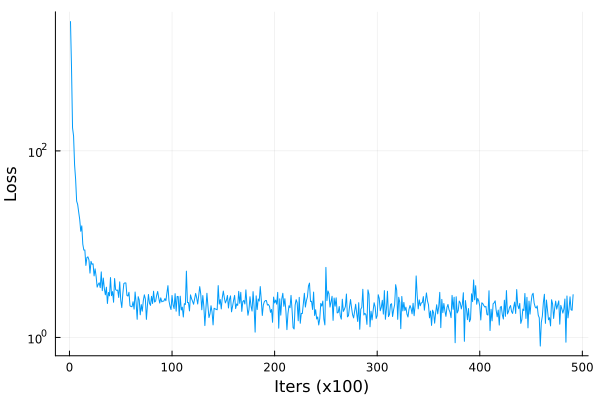

LoadError: InterruptException:

In [24]:
for iter in 1:5000000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    T = rand(timesteps)
    # T = rand(timesteps)
    # T = fill(T, batch_size)
    diffusedOH = sampleforward(P, T, datOH)

    # Forward pass and loss computation
    loss, grads = Flux.withgradient(params) do
        output = model(diffusedOH, T)  # T is now directly usable
        # @show output
        # @show standardloss(P, T, output, datOH)[1]
        -standardloss(P, T, model(diffusedOH, T), datOH)[1]
    end
    
    # Update parameters
    Flux.update!(opt, params, grads)
    
    cumu_loss += loss
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/100)  # Changed from 100 to 50 to match the iteration count
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

In [33]:
# Sample a batch
x = hcat([target_sample() for i in 1:batch_size]...)
datOH = onehotbatch(x, 1:alph)

# Sample time steps
t = rand(timesteps)
# T = [t for i in 1:batch_size]  # Scale to the range [0, timesteps-1]

# t = rand(Float32) * (Float32(timesteps) - 1)  # Sample a single Float32 time
T = fill(t, batch_size) 

# Forward pass
diffusedOH = sampleforward(P, T, datOH)
output = model(diffusedOH, T)

# Compute loss
loss = standardloss(P, T, output, datOH)

# Try to compute gradients

loss, grads = Flux.withgradient(params) do
    output = model(diffusedOH, T)
    -standardloss(P, T, output, datOH)[1]
end

LoadError: MethodError: no method matching (::DIT)(::Array{Bool, 3}, ::Vector{Float32})

[0mClosest candidates are:
[0m  (::DIT)(::AbstractArray, [91m::Real[39m)
[0m[90m   @[39m [35mMain[39m [90m[4mIn[17]:21[24m[39m


# Training

In [34]:
#Since this IndependentDiscreteDiffusion process is equivalent, the model from above should be "pre-trained"
#let's check if the loss resumes from where it left off
for iter in 1:5000000
    x = hcat([target_sample() for i in 1:batch_size]...)
    datOH = onehotbatch(x, 1:alph)

    T = rand(timesteps)

    # a = P.α(T)
    # scal = a[2]./(1 .- a[1]) 

    diffusedOH = sampleforward(P, T, datOH) #Note, we diffuse the one-hots
    l,gs = Flux.withgradient(ps) do
        # -Flux.logitcrossentropy(model(diffusedOH,T), datOH).*scal
        -standardloss(P, T, model(diffusedOH,T), datOH)[1]
    end

    
    # Update parameters
    Flux.Optimise.update!(opt, ps, gs)
    cumu_loss += loss
    # cumu_loss += l
    if mod(iter,100) == 0
        opt[2].eta = opt[2].eta * 0.997
        push!(training_losses, cumu_loss/100)
        cumu_loss = 0.0
        IJulia.clear_output(true)
        plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none) |> IJulia.display
        sleep(0.01)
    end
end
IJulia.clear_output(true)
plot(training_losses, yscale = :log10, ylabel = "Loss", xlabel = "Iters (x100)", label = :none)

LoadError: UndefVarError: `ps` not defined

# Evaluation

In [ ]:
function zero_sample(x_t, t)
    vocab_size, seq_length, batch_size = size(x_t)
    sm = softmax(model(x_t, t))
    sampled = zeros(Bool, size(x_t))
    for b in 1:batch_size
        for s in 1:seq_length
            probs = sm[:, s, b]
            sampled_token = randcat(rng, probs)
            sampled[:, s, b] = onehotbatch([sampled_token], 1:vocab_size)
        end
    end
    return sampled
end

eq = Categorical(ones(alph)./alph)
N = 1000
seq_length = 3

# Initialize x_T with mask tokens
x_T = falses(alph, seq_length, N)
x_T[5, :, :] .= true  # Assuming 5 is the mask token index

@time samp = samplebackward(zero_sample, P, timesteps, x_T)

# Convert the result to the desired format
diff_samples = [onecold(samp[:, :, i], 1:alph) for i in 1:N];

In [ ]:
target_samples = [target_sample() for i in 1:N];
prop_d = proportionmap(diff_samples)
target_d = proportionmap(target_samples)
diff_freqs = [get(prop_d,a,0.0) for a in all_seqs]
target_freqs = [get(target_d,a,0.0) for a in all_seqs]

pl = groupedbar([join(string.(a)) for a in all_seqs], [all_probs target_freqs diff_freqs],
    xrotation = 90, size = (800,250), label = ["True Frequencies" "Target Samples (N=$(N))" "Diffusion Samples  (N=$(N))"],
    color = ["red" "Green" "blue"], margins = 0.5Plots.cm, xlim = (0,65))
savefig(pl,"discrete_diff_fluxIJ.pdf")
pl

# Random Things

In [1]:
using Transformers
using Transformers.TextEncoders
using Transformers.HuggingFace
using Transformers.Datasets
using Transformers.Datasets: GLUE

using Flux
using Flux.Losses
using Zygote
import Optimisers

const Epoch = 2
const Batch = 4
const mnli = GLUE.MNLI(false)
const labels = Vocab([get_labels(mnli)...])

function preprocess(batch)
    global bertenc, labels
    data = encode(bertenc, map(collect, zip(batch[1], batch[2])))
    label = lookup(OneHot, labels, batch[3])
    return merge(data, (label = label,))
end

# load the old config file and update some value
const bert_config = HuggingFace.HGFConfig(hgf"bert-base-uncased:config"; num_labels = length(labels))

# load the model / tokenizer with new config
const _bert_model = load_model("bert-base-uncased", :ForSequenceClassification; config = bert_config)
const bertenc = load_tokenizer("bert-base-uncased"; config = bert_config)

const bert_model = todevice(_bert_model)

const opt_rule = Optimisers.Adam(1e-6)
const opt = Optimisers.setup(opt_rule, bert_model)

function acc(p, label)
    pred = Flux.onecold(p)
    truth = Flux.onecold(label)
    sum(pred .== truth) / length(truth)
end

function loss(model, input)
    nt = model(input)
    p = nt.logit
    l = logitcrossentropy(p, input.label)
    return l, p
end

function train!()
    global Batch, Epoch, bert_model
    @info "start training: $(args["task"])"
    for e = 1:Epoch
        @info "epoch: $e"
        datas = dataset(Train, mnli)
        i = 1
        al = zero(Float64)
        while (batch = get_batch(datas, Batch)) !== nothing
            input = todevice(preprocess(batch::Vector{Vector{String}}))
            (l, p), back = Zygote.pullback(bert_model) do model
                loss(model, input)
            end
            a = acc(p, input.label)
            al += a
            (grad,) = back((Zygote.sensitivity(l), nothing))
            i += 1
            Optimisers.update!(opt, bert_model, grad)
            mod1(i, 16) == 1 && @info "training" loss=l accuracy=al/i
        end

        test()
    end
end

function test()
    @info "testing"
    i = 1
    al = zero(Float64)
    datas = dataset(Dev, mnli)
    while (batch = get_batch(datas, Batch)) !== nothing
        input = todevice(preprocess(batch))
        p = bert_model(input).logit
        a = acc(p, input.label)
        al += a
        i+=1
    end
    al /= i
    @info "testing" accuracy = al
    return al
end


test (generic function with 1 method)